In [1]:
import os
from utils import *

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

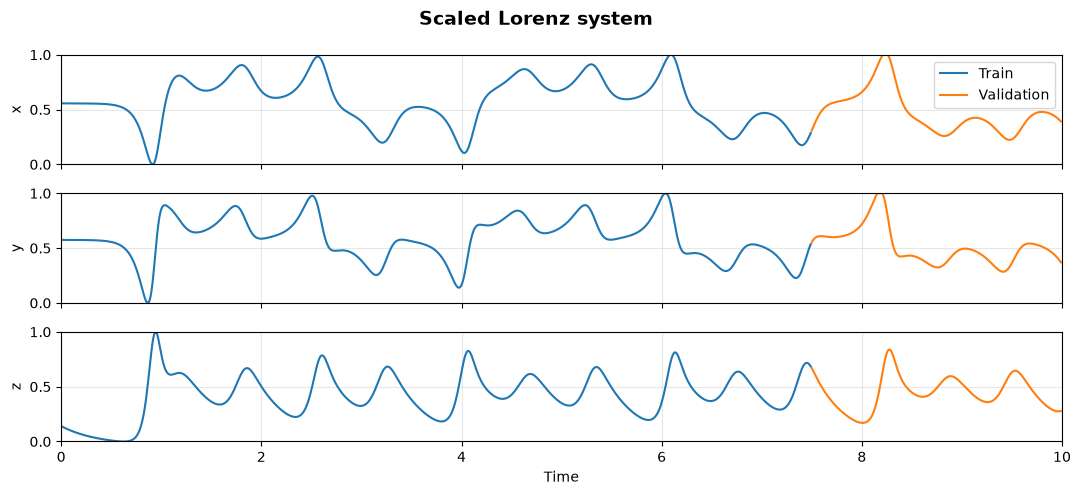

In [2]:
npoints = 1000
h = 0.01
params = [10, 28, 8 / 3]
init_point = [0, -0.01, 9]

dataset = generate_lorenz(
    npoints, 
    h,
    params, 
    init_point
)

# Trin test split
dataset_train, dataset_val = train_test_split(
    dataset,
    test_size=0.25,
    shuffle=False
)
time = np.arange(npoints) * h

time_tr = time[:len(dataset_train)]
time_val = time[len(dataset_train):]

# Scale the data to the range [0, 1]
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
val_scaled = scaler.transform(dataset_val)
val_scaled = np.clip(val_scaled, 0, 1)

plot_lorenz(train_scaled, val_scaled, time_tr, time_val)

# VQC combined with MLP

In this section, we extend the independent-channel architecture introduced previously by appending a two-layer multilayer perceptron (MLP). The network uses the ReLU activation function, and the mapping is given by:

$$
\phi_{mlp}  :\mathbb{R}^C \rightarrow \mathbb{R}^{2C\times S} \rightarrow \mathbb{R}^{C\times S}
$$

This architecture naturally supports forecasting horizons $S>1$ by simply adjusting the output dimension of the final layer.

In [3]:
# Params
batch_size = 128 
n_chanels = 3
window_size = 5
batch_size = 128
nreps = 24
nqubits = window_size
weights = {"theta": (3 * nqubits * nreps,)} # Strongly entangling layers

# Training hyperparameters
epochs = 50
lr = 5e-4

In [4]:
# Create the PennyLane QNode
dev = qml.device("lightning.qubit", wires=nqubits)

def indep_chanel_vqc(inputs, theta):
    angle_encoding(nqubits, inputs)
    VQC_strong(nqubits, theta, nreps)
    return qml.expval(qml.Z(0))

indep_chanel_vqc_node = qml.QNode(
    func=indep_chanel_vqc,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)
# Create the MLP post-processing model
class VQCMLPModel(nn.Module):
    def __init__(self, chanels, horizon):
        super().__init__()

        self.vqc_x = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_y = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)
        self.vqc_z = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

        self.mlp = nn.Sequential(
            nn.Linear(chanels, 2*chanels*horizon),   
            nn.ReLU(),
            nn.Linear(2*chanels*horizon, chanels*horizon)     
        )

    def forward(self, x):
        # x shape: (batch, window_size, channels)
        x_ch = x[:, :, 0]
        y_ch = x[:, :, 1]
        z_ch = x[:, :, 2]

        qx = self.vqc_x(x_ch)
        qy = self.vqc_y(y_ch)
        qz = self.vqc_z(z_ch)

        q_features = torch.stack([qx, qy, qz], dim=1)

        return self.mlp(q_features)

## Short term forecasting

In [5]:
# Create the sequences
horizon_short = 1

x_tr_short, hor_tr_short = create_sequences(train_scaled, window_size, horizon_short)
x_val_short, hor_val_short = create_sequences(val_scaled, window_size, horizon_short)

x_tr_short = torch.from_numpy(x_tr_short).double()
hor_tr_short = torch.from_numpy(hor_tr_short).double()

x_val_short = torch.from_numpy(x_val_short).double()
hor_val_short = torch.from_numpy(hor_val_short).double()

tr_dataset_short = TensorDataset(x_tr_short, hor_tr_short)
tr_loader_short = DataLoader(tr_dataset_short, batch_size=batch_size, shuffle=False)

In [6]:
# reset_seeds(SEED)

# # Create the model
# model_VQCMLP_short = VQCMLPModel(n_chanels, horizon_short)
# model_VQCMLP_short.double()

# # Define optimizer and loss function
# opt_short = torch.optim.Adam(params=model_VQCMLP_short.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# # Save the best model
# best_state_short = None
# best_val_loss_short = float("inf")

# history_short = {"Loss": [], "Val loss": []}

# print(30 * "#")
# print("Starting training")
# print(30 * "#")

# for epoch in range(epochs):

#     #Training
#     model_VQCMLP_short.train()
#     epoch_loss = 0
#     for xb, yb in tr_loader_short:
#         opt_short.zero_grad()
#         pred = model_VQCMLP_short(xb)
#         target = yb.reshape(yb.shape[0], -1)
#         loss = loss_fn(pred, target)    
#         loss.backward()
#         opt_short.step()
#         epoch_loss += loss.item()
    
#     # Store average loss for this epoch
#     epoch_loss /= len(tr_loader_short)
#     history_short["Loss"].append(epoch_loss)

#     # Evaluation
#     model_VQCMLP_short.eval()
#     with torch.no_grad():
#         val_pred = model_VQCMLP_short(x_val_short)
#         val_target = hor_val_short.reshape(hor_val_short.shape[0], -1)
#         val_loss = loss_fn(val_pred, val_target).item()

#     # Store val loss
#     history_short["Val loss"].append(val_loss)

#     # Save best model
#     if val_loss < best_val_loss_short:
#         best_val_loss_short = val_loss
#         best_state_short = {
#             name: params.detach().clone()
#             for name, params in model_VQCMLP_short.state_dict().items()
#         }

#     # Print training progress every 5 epochs
#     if epoch == 0 or (epoch + 1) % 5 == 0:
#         print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


# if best_state_short is not None:
#     model_VQCMLP_short.load_state_dict(best_state_short)

In [7]:
# # Save the model
# os.makedirs("../models_states", exist_ok=True)

# checkpoint = {
#     "vqc_mlp_short": model_VQCMLP_short.state_dict(),
#     "history": history_short
# }
# torch.save(checkpoint, "../models_states/vqc_mlp_short.pt")

In [8]:
# Load the model
checkpoint = torch.load(
    "../models_states/vqc_mlp_short.pt",
    map_location="cpu"
)

history_short = checkpoint["history"]

model_VQCMLP_short = VQCMLPModel(n_chanels, horizon_short).double()
model_VQCMLP_short.load_state_dict(checkpoint["vqc_mlp_short"])

<All keys matched successfully>

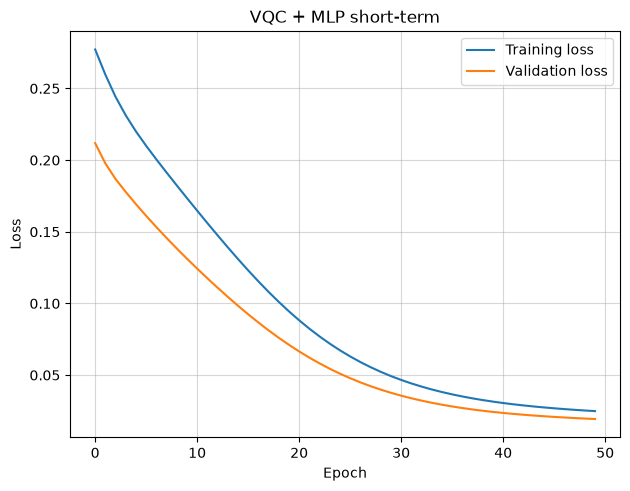

In [9]:
plot_loss(history_short, "VQC + MLP short-term")

In [10]:
# Evaluation mode
model_VQCMLP_short.eval()

with torch.no_grad():
    pred_short = model_VQCMLP_short(x_val_short)

pred_short_3d = pred_short.reshape(pred_short.shape[0], horizon_short, n_chanels)
target_short_3d = hor_val_short

# =====================
# RMSE
# =====================

squared_error = (pred_short_3d - target_short_3d) ** 2
mean_rmse_list_short = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_short = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_short_3d - target_short_3d)
mean_mae_list_short = abs_error.mean(dim=(1, 2))
mean_mae_short = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_short_3d - pred_short_3d) / (target_short_3d + eps))
mean_mape_list_short = percentage_error.mean(dim=(1, 2))
mean_mape_short = percentage_error.mean()

print(f"Global RMSE short forecasting: {mean_rmse_short:.4f}")
print(f"Global MAE short forecasting: {mean_mae_short:.4f}")
print(f"Global MAPE short forecasting: {mean_mape_short:.4f}")

Global RMSE short forecasting: 0.1391
Global MAE short forecasting: 0.1076
Global MAPE short forecasting: 0.2527


In [11]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "short-term",
        "model": "VQC + MPL",
        "MAPE": mean_mape_short,
        "MAE": mean_mae_short,
        "RMSE": mean_rmse_short,
    },
)

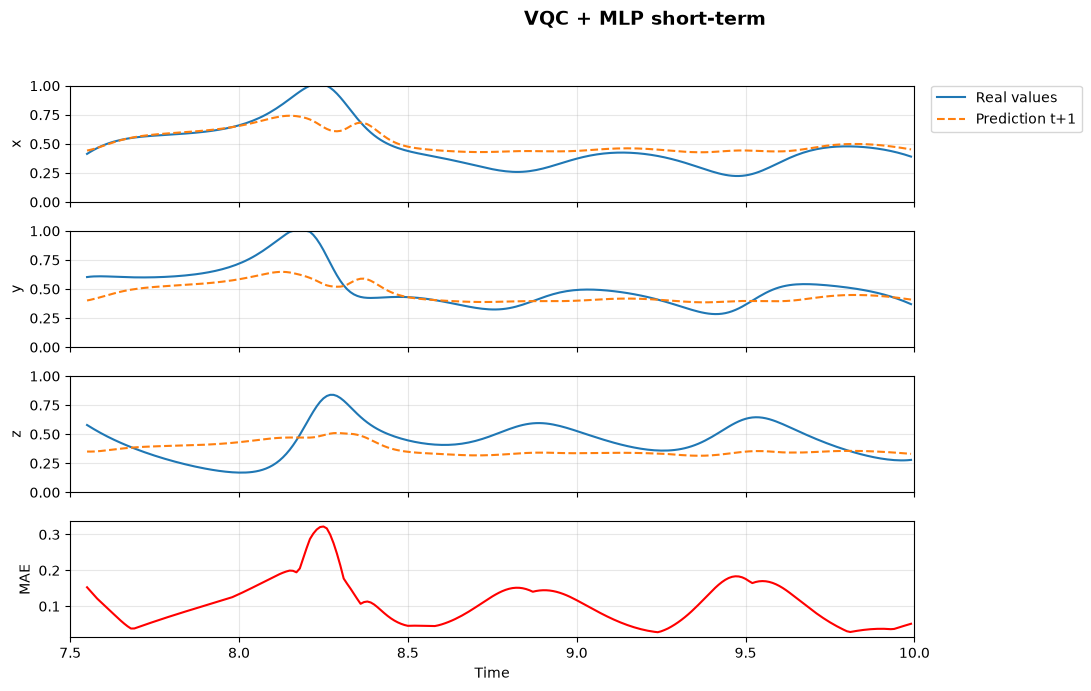

In [12]:
pred_x_short = pred_short_3d[:, :, 0]
pred_y_short = pred_short_3d[:, :, 1]
pred_z_short = pred_short_3d[:, :, 2]

plot_preds_and_error(
    pred_x_short,
    pred_y_short,
    pred_z_short,
    mean_mae_list_short,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_short,
    horizon_step=1,
    title="VQC + MLP short-term"
)

# Long term forecasting

In [13]:
# Create the sequences
horizon_long = 5

x_tr_long, hor_tr_long = create_sequences(train_scaled, window_size, horizon_long)
x_val_long, hor_val_long = create_sequences(val_scaled, window_size, horizon_long)

x_tr_long = torch.from_numpy(x_tr_long).double()
hor_tr_long = torch.from_numpy(hor_tr_long).double()

x_val_long = torch.from_numpy(x_val_long).double()
hor_val_long = torch.from_numpy(hor_val_long).double()

tr_dataset_long = TensorDataset(x_tr_long, hor_tr_long)
tr_loader_long = DataLoader(tr_dataset_long, batch_size=batch_size, shuffle=False)

In [14]:
# reset_seeds(SEED)

# # Create the model
# model_VQCMLP_long = VQCMLPModel(n_chanels, horizon_long)
# model_VQCMLP_long.double()

# # Define optimizer and loss function
# opt_long = torch.optim.Adam(params=model_VQCMLP_long.parameters(), lr=lr)
# loss_fn = nn.MSELoss()

# # Save the best model
# best_state_long = None
# best_val_loss_long = float("inf")

# history_long = {"Loss": [], "Val loss": []}

# print(30 * "#")
# print("Starting training")
# print(30 * "#")

# for epoch in range(epochs):

#     #Training
#     model_VQCMLP_long.train()
#     epoch_loss = 0
#     for xb, yb in tr_loader_long:
#         opt_long.zero_grad()
#         pred = model_VQCMLP_long(xb) # shape: (batch, 15)
#         target = yb.reshape(yb.shape[0], -1) # yb shape: (batch, 5, 3)
#         loss = loss_fn(pred, target)
#         loss.backward()
#         opt_long.step()
#         epoch_loss += loss.item()
    
#     # Store average loss for this epoch
#     epoch_loss /= len(tr_loader_long)
#     history_long["Loss"].append(epoch_loss)

#     # Evaluation
#     model_VQCMLP_long.eval()
#     with torch.no_grad():
#         val_pred = model_VQCMLP_long(x_val_long)
#         val_target = hor_val_long.reshape(hor_val_long.shape[0], -1)
#         val_loss = loss_fn(val_pred, val_target).item()

#     # Store val loss
#     history_long["Val loss"].append(val_loss)

#     # Save best model
#     if val_loss < best_val_loss_long:
#         best_val_loss_long = val_loss
#         best_state_long = {
#             name: params.detach().clone()
#             for name, params in model_VQCMLP_long.state_dict().items()
#         }

#     # Print training progress every 5 epochs
#     if epoch == 0 or (epoch + 1) % 5 == 0:
#         print(f"Epoch: {epoch + 1} | Loss: {epoch_loss:.4f} | Validation loss: {val_loss:.4f}")


# if best_state_long is not None:
#     model_VQCMLP_long.load_state_dict(best_state_long)

In [15]:
# # Save the model
# os.makedirs("models_states", exist_ok=True)

# checkpoint = {
#     "vqc_mlp_long": model_VQCMLP_long.state_dict(),
#     "history": history_long
# }
# torch.save(checkpoint, "models_states/vqc_mlp_long.pt")

In [16]:
# Load the model
checkpoint = torch.load(
    "../models_states/vqc_mlp_long.pt",
    map_location="cpu"
)

history_long = checkpoint["history"]

model_VQCMLP_long = VQCMLPModel(n_chanels, horizon_long).double()
model_VQCMLP_long.load_state_dict(checkpoint["vqc_mlp_long"])

<All keys matched successfully>

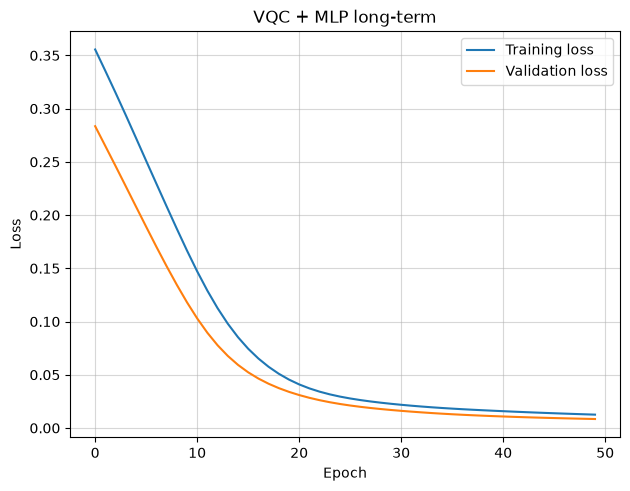

In [17]:
plot_loss(history_long, "VQC + MLP long-term")

In [18]:
# Evaluation mode
model_VQCMLP_long.eval()

with torch.no_grad():
    pred_long = model_VQCMLP_long(x_val_long)

pred_long_3d = pred_long.reshape(pred_long.shape[0], horizon_long, n_chanels)
target_long_3d = hor_val_long

# =====================
# RMSE
# =====================

squared_error = (pred_long_3d - target_long_3d) ** 2
mean_rmse_list_long = torch.sqrt(squared_error.mean(dim=(1, 2)))
mean_rmse_long = torch.sqrt(squared_error.mean())

# =====================
# MAE
# =====================

abs_error = torch.abs(pred_long_3d - target_long_3d)
mean_mae_list_long = abs_error.mean(dim=(1, 2))
mean_mae_long = abs_error.mean()

# =====================
# MAPE
# =====================

eps = 1e-8

percentage_error = torch.abs((target_long_3d - pred_long_3d) / (target_long_3d + eps))
mean_mape_list_long = percentage_error.mean(dim=(1, 2))
mean_mape_long = percentage_error.mean()

# =====================
# MAE in t+5 (for the plot)
# =====================

h = 4  # t+5

abs_error_t5 = torch.abs(pred_long_3d[:, h, :] - target_long_3d[:, h, :])
mean_mae_t5_list = abs_error_t5.mean(dim=1)

print(f"Global RMSE long forecasting: {mean_rmse_long:.4f}")
print(f"Global MAE long forecasting: {mean_mae_long:.4f}")
print(f"Global MAPE long forecasting: {mean_mape_long:.4f}")

Global RMSE long forecasting: 0.0919
Global MAE long forecasting: 0.0654
Global MAPE long forecasting: 0.1520


In [19]:
# Save the results to a CSV file
save_result_csv(
    "../results/lorenz_metrics.csv",
    {
        "forecasting": "long-term",
        "model": "VQC + MPL",
        "MAPE": mean_mape_long,
        "MAE": mean_mae_long,
        "RMSE": mean_rmse_long,
    },
)

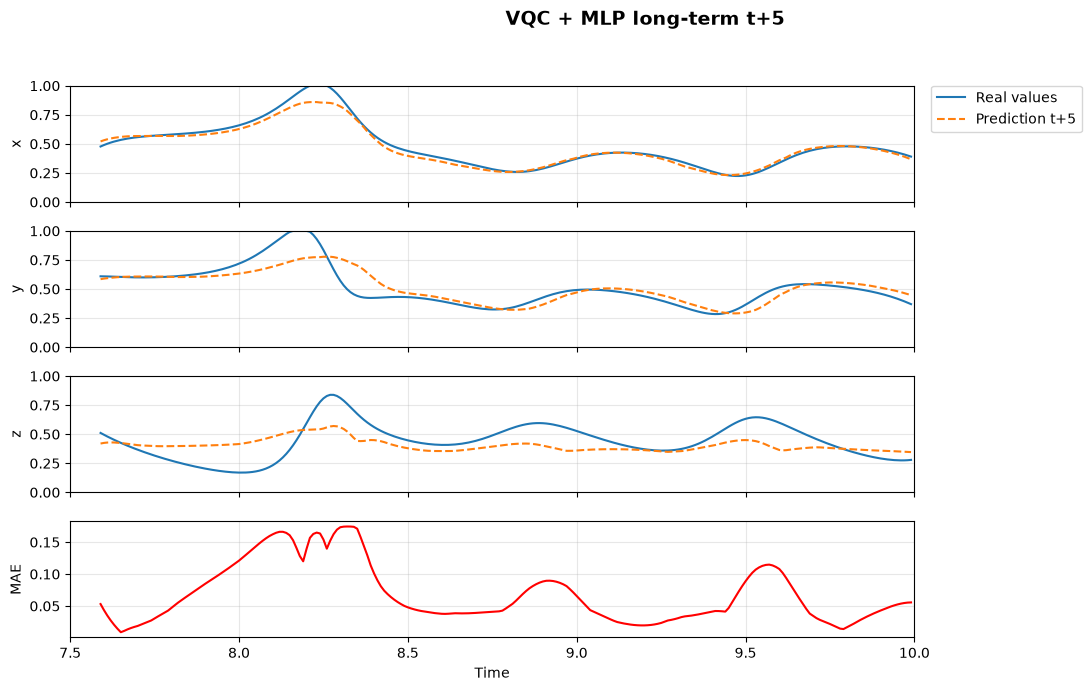

In [20]:
pred_x_long = pred_long_3d[:, :, 0]
pred_y_long = pred_long_3d[:, :, 1]
pred_z_long = pred_long_3d[:, :, 2]

plot_preds_and_error(
    pred_x_long,
    pred_y_long,
    pred_z_long,
    mean_mae_t5_list,
    time_val,
    window_size,
    val_scaled,
    error="MAE",
    horizon=horizon_long,
    horizon_step=5,
    title="VQC + MLP long-term t+5"
)